In [1]:
import sys
#lets you access python's runtime environment
from pathlib import Path
#sys.path is a built in variable in the sys module and contains a list of directories that is seached through when you do an import
#so we are appending the src directory to that
sys.path.append(str(Path().resolve().parent / "src"))
import config

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

df_path= config.PROJECT_ROOT/ "data" / "cleaned.csv"
panel_data_path = config.PROJECT_ROOT/ "data" / "panel_data.csv"
panel_data = pd.read_csv(panel_data_path)


In [2]:
train = panel_data[panel_data['Year'] <= 2022].copy()

All analysis is restricted to the training set (years up to and including 2022) to avoid leakage.

Churn rate is highest among lifters in their first year of competition and declines as career length increases, until career length reaches certain threshold.

### Number of Meets: Distribution and Relationship to Churn

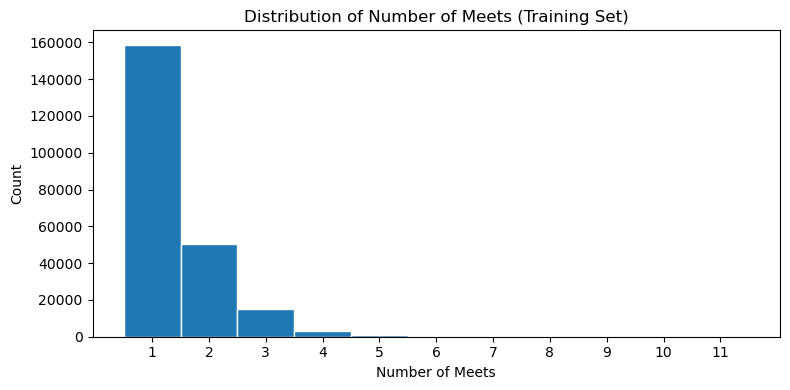

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train['NumberOfMeets'].dropna(), 
        bins=range(1, int(train['NumberOfMeets'].max()) + 2), 
        edgecolor='white', align='left')
ax.set_title('Distribution of Number of Meets (Training Set)')
ax.set_xlabel('Number of Meets')
ax.set_ylabel('Count')
ax.set_xticks(range(1, int(train['NumberOfMeets'].max()) + 1))
plt.tight_layout()
plt.show()

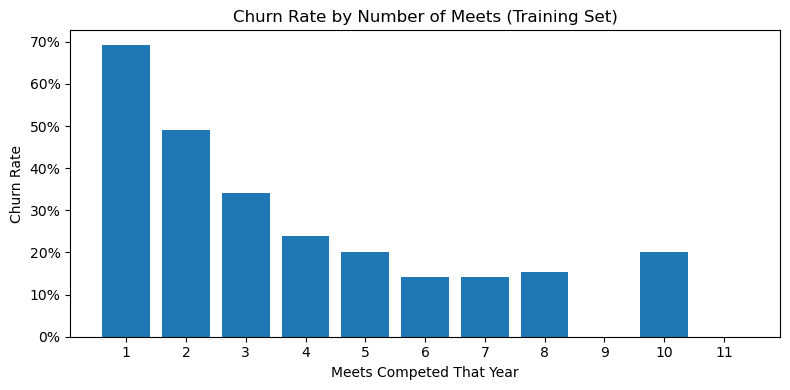

In [4]:
meets_churn = (
    train.groupby('NumberOfMeets')['Churns']
    .mean()
    .reset_index(name='ChurnRate')
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(meets_churn['NumberOfMeets'].astype(str), meets_churn['ChurnRate'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Churn Rate by Number of Meets (Training Set)')
ax.set_xlabel('Meets Competed That Year')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

Lifters who compete more frequently in a given year are substantially less likely to churn. The number of lifters competing more than 6 times a year is very small, and so this makes the relationship weaker past this point as it is more random.

### Average Meets Per Year: Distrubution and Relationship to Churn

`AvgMeetsPerYear` captures a lifter's historical participation pattern and is the average meets a lifter has done in each calendar year since their first competition.

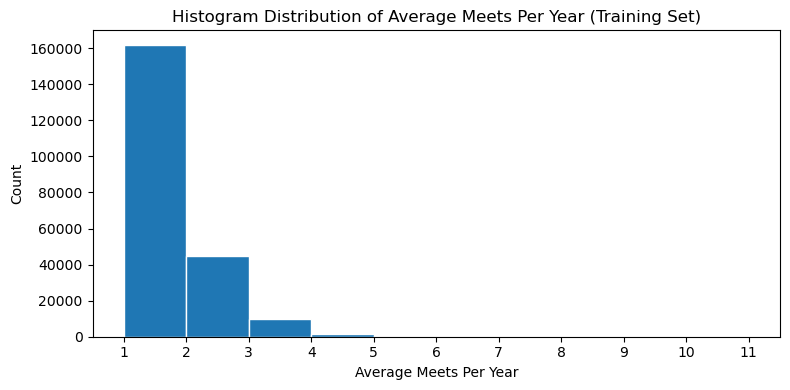

In [5]:


max_val = int(train['AvgMeetsPerYear'].dropna().clip(upper=10).max()) + 1
bins = range(1, max_val + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train['AvgMeetsPerYear'].clip(upper=10).dropna(), bins=bins, edgecolor='white')
ax.set_title('Histogram Distribution of Average Meets Per Year (Training Set)')
ax.set_xlabel('Average Meets Per Year')
ax.set_ylabel('Count')
ax.set_xticks(range(1, max_val + 1))
plt.tight_layout()
plt.show()

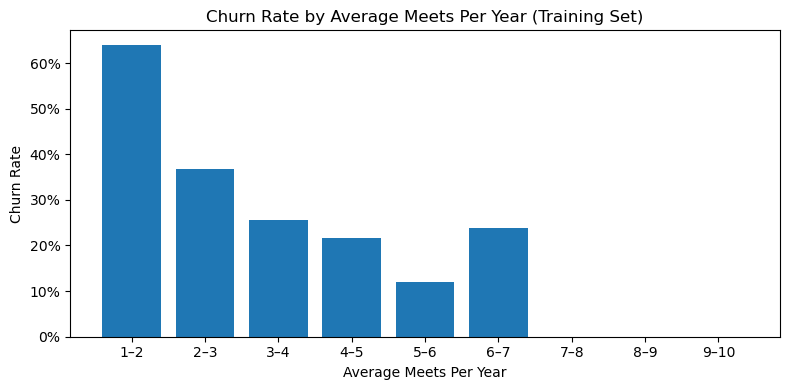

In [6]:
max_val = int(train['AvgMeetsPerYear'].clip(upper=10).max()) + 1
bins = list(range(1, max_val + 1))
labels = labels = [f'{i}–{i+1}' for i in range(1, max_val)]

avg_meets_churn = (
    train.assign(AvgMeetsBand=pd.cut(
        train['AvgMeetsPerYear'].clip(upper=max_val),
        bins=bins,
        labels=labels,
        include_lowest=True
    ))
    .groupby('AvgMeetsBand', observed=True)['Churns']
    .mean()
    .reset_index(name='ChurnRate')
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(avg_meets_churn['AvgMeetsBand'].astype(str), avg_meets_churn['ChurnRate'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Churn Rate by Average Meets Per Year (Training Set)')
ax.set_xlabel('Average Meets Per Year')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

A similar pattern holds for average meets per year. Lifters with a higher historical participation rate churn at lower rates. This feature captures longer-term engagement rather than just current-year activity.

### Churn Rate by Career Stage

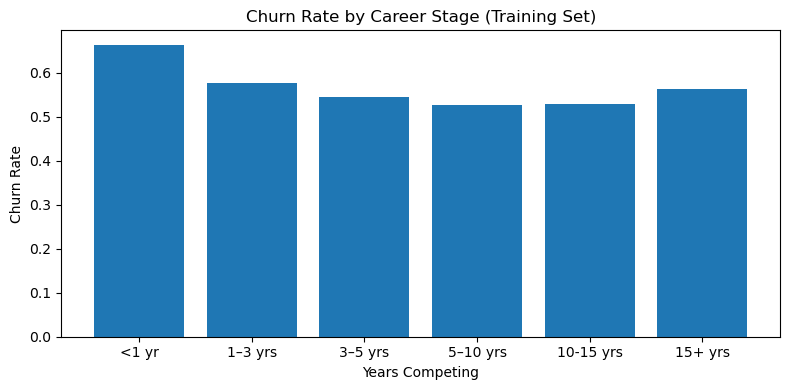

In [7]:

train_career = train.copy()
train_career['CareerYears'] = train_career['TimeCompetingYearEnd'] / 365
train_career['CareerBand'] = pd.cut(
    train_career['CareerYears'],
    bins=[0, 1, 3, 5, 10, 15, float('inf')],
    labels=['<1 yr', '1–3 yrs', '3–5 yrs', '5–10 yrs', '10-15 yrs', '15+ yrs']
)
career_churn = train_career.groupby('CareerBand', observed=True)['Churns'].mean().reset_index(name='ChurnRate')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(career_churn['CareerBand'].astype(str), career_churn['ChurnRate'])
ax.set_title('Churn Rate by Career Stage (Training Set)')
ax.set_xlabel('Years Competing')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()



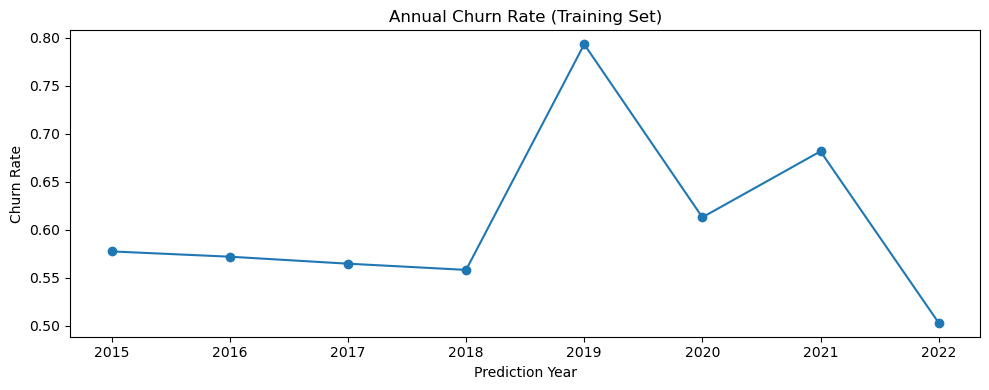

In [8]:
churn_by_year = train.groupby('Year')['Churns'].mean().reset_index(name='ChurnRate')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(churn_by_year['Year'], churn_by_year['ChurnRate'], marker='o')
ax.set_xlabel('Prediction Year')
ax.set_ylabel('Churn Rate')
ax.set_title('Annual Churn Rate (Training Set)')
plt.tight_layout()
plt.show()

Note that the churn corresponds to whether a particular lifter competes the *following year*. Hence the spike in 2019 is likely due to COVID the following year. 


### Missing Data

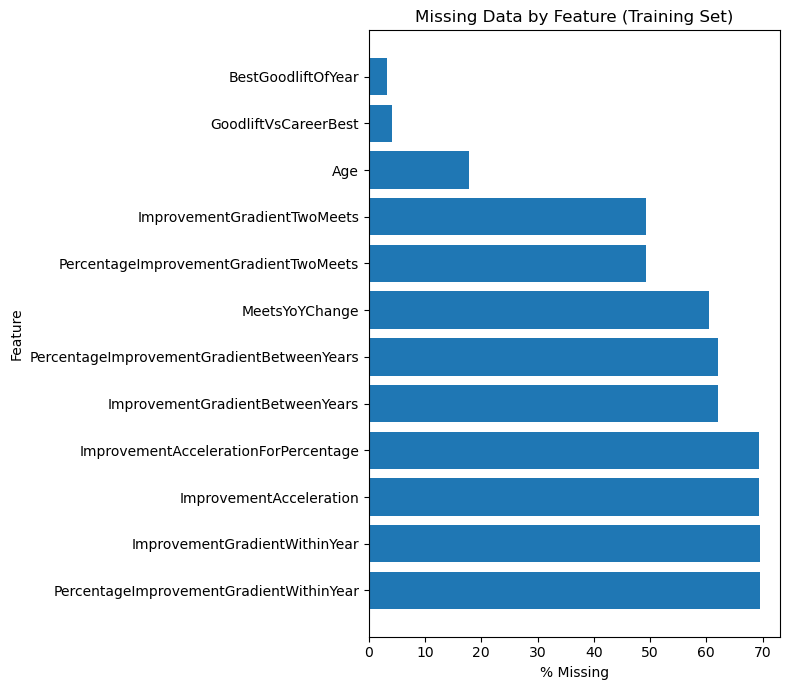

In [9]:
missing = train.isnull().sum(axis=0)
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})

fig, ax = plt.subplots(figsize=(8, len(missing_df) * 0.5 + 1))
ax.barh(missing_df.index, missing_df['Percentage'])
ax.set_title('Missing Data by Feature (Training Set)')
ax.set_xlabel('% Missing')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()



#### Known reasons for NaN 

Missing values are present in several features

**Improvement gradient features** : `ImprovementGradientTwoMeets`, `ImprovementGradientBetweenYears`, `ImprovementGradientWithinYear`, `ImprovementAcceleration`, and their percentage variants are `NaN` due to insufficient meet history to calculate the relevant features. `HistGradientBoostingClassifier` handles `NaN` natively.

**`MeetsYoYChange`** : `NaN` for a lifter's first year as there is no previous year to compute a year-on-year difference against.

#### Missingness due to data entry inconsistencies

**`Age`** : age is not consistently recorded across meets and federations in the OpenPowerlifting dataset. 

**Goodlift features** : `Goodlift`, `BestGoodliftOfYear`, and `GoodliftVsCareerBest` are missing where Goodlift points were not recorded for a meet. `GoodliftVsCareerBest` additionally produces `NaN` where `CareerBestGoodlift` is zero, handled by replacing the denominator with `NaN` before division.



In [10]:
grouped = train.groupby(['Year', 'Churns'])['Age']
#looking at churn vs no churn per year
#proportion of missing values
missing_rates_age = grouped.apply(lambda x: x.isna().mean())

rates_age = missing_rates_age.unstack()
rates_age = rates_age * 100
rates_age = rates_age.rename(columns={
    0: 'MissingPctNonChurn',
    1: 'MissingPctChurn'
})
rates_age['Diff'] = rates_age['MissingPctChurn'] - rates_age['MissingPctNonChurn']

rates_age

Churns,MissingPctNonChurn,MissingPctChurn,Diff
Year,,,
2015,18.362168,32.410767,14.048599
2016,17.388630,21.196581,3.807951
2017,16.617510,22.079290,5.461781
2018,13.615588,18.589377,4.973789
2019,10.829684,16.918289,6.088605
2020,7.619187,13.309950,5.690763
2021,15.771567,8.521857,-7.249710
2022,17.656215,28.933304,11.277089


The table above shows the percentage of missing `Age` values for churners and non-churners by year, along with the difference between the two groups.

The relationship between missing Age and churn is not stable over time (including a sign flip in 2021). Therefore do not want model to learn from missingness, so will impute with median age of that year to prevent model from learning from unstable pattern. Median age for that year used (rather than whole dataset) to prevent data leakage.

Missing `Age` carries a consistent positive signal. Churners have higher missingness rates than non-churners in all years except 2021. The 2021 anomaly is may be Covid-related but this cannot be determined. A binary `AgeMissing` indicator is added to allow the model to learn from the missingness pattern explicitly. `Age` is then imputed with the median age for that year (rather than the whole dataset) to prevent data leakage, giving the model the option to ignore the missingness signal if it proves unreliable.

In [11]:
panel_data['AgeMissing'] = panel_data['Age'].isna().astype(int)
panel_data['Age'] = panel_data['Age'].fillna(panel_data.groupby('Year')['Age'].transform('median'))

In [12]:
grouped = train.groupby(['Year', 'Churns'])['BestGoodliftOfYear']
#looking at churn vs no churn per year
#proportion of missing values
missing_rates_gl = grouped.apply(lambda x: x.isna().mean())

rates_gl = missing_rates_gl.unstack()
rates_gl = rates_gl*100

rates_gl = rates_gl.rename(columns={
    0: 'MissingPctNonChurn',
    1: 'MissingPctChurn'
})

rates_gl['diff'] = rates_gl['MissingPctChurn'] - rates_gl['MissingPctNonChurn']
rates_gl

Churns,MissingPctNonChurn,MissingPctChurn,diff
Year,,,
2015,1.591696,4.067167,2.475472
2016,1.520077,4.266930,2.746852
2017,1.589814,4.225118,2.635304
2018,1.744046,4.635446,2.891400
2019,1.574151,3.546340,1.972189
2020,2.559228,5.695034,3.135806
2021,1.409478,3.691104,2.281626
2022,1.504707,3.960758,2.456052


The table above shows the percentage of missing `BestGoodliftOfYear` values for churners and non-churners by year.

`BestGoodliftOfYear` being missing carries weak churn signal that is stable over time. Will leave `NaN` and let model handle this natively.

In [13]:
#exporting now imputed missing age values

imputed_path = config.PROJECT_ROOT/ "data" / "panel_data_imputed.csv"
panel_data.to_csv(imputed_path, index = False)
